In [ ]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

data = pd.read_csv('../../data/openpowerlifting.csv')


data.dropna(axis=0, how='any', inplace=True)
data = data[data['Sex'] != 'F']

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
data[['BestSquatKg', 'BestDeadliftKg']]


,BestSquatKg,BestDeadliftKg
2574,165.00,200.00
2720,117.50,182.50
2785,137.50,182.50
2814,240.00,300.00
3972,147.50,195.00
3973,147.50,195.00
4206,67.50,105.00
4209,92.50,112.50
4688,95.00,167.50
4747,195.00,237.50


In [ ]:
# Drop rows where any column in X or y has NaN



X_full, X_test, y_full, y_test = train_test_split(
    data[['BestSquatKg']], data[["BestDeadliftKg"]]
)

X_full["BestSquatKg"].fillna(X_full["BestSquatKg"].mean(), inplace=True)
y_full["BestDeadliftKg"].fillna(y_full["BestDeadliftKg"].mean(), inplace=True)


C:\Users\user\AppData\Local\Temp\ipykernel_10008\107457688.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_full["BestSquatKg"].fillna(X_full["BestSquatKg"].mean(), inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_10008\107457688.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X_full, y_full)

type(X_train)


pandas.core.frame.DataFrame

In [ ]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)


y_scaler = MinMaxScaler()
y_train = y_scaler.fit_transform(y_train)
y_valid = y_scaler.transform(y_valid)
y_test  = y_scaler.transform(y_test)

type(y_train)
type(X_train)

numpy.ndarray

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_mae",
    patience=3,
    restore_best_weights=True
)

In [ ]:
model = keras.models.Sequential([
    keras.layers.Dense(32, activation='relu',  input_shape=(X_train.shape[1],)),
    keras.layers.Dense(1)
])

model.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=0.001), metrics=['mae'])

c:\Users\user\Desktop\machine_learning\ts_env\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
import matplotlib.pyplot as plt

history = model.fit(
    X_train, y_train,
    epochs=30,  
    validation_data=(X_valid, y_valid),
    callbacks=[early_stop])


Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.2838 - mae: 0.4699 - val_loss: 0.3097 - val_mae: 0.4667
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.2759 - mae: 0.4626 - val_loss: 0.3019 - val_mae: 0.4597
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.2683 - mae: 0.4556 - val_loss: 0.2945 - val_mae: 0.4528
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 0.2611 - mae: 0.4487 - val_loss: 0.2872 - val_mae: 0.4459
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 0.2539 - mae: 0.4419 - val_loss: 0.2800 - val_mae: 0.4391
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.2469 - mae: 0.4350 - val_loss: 0.2729 - val_mae: 0.4322
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - loss: 0.2400 - mae: 0.4282 - val_loss: 0.2660 - val_mae: 0.4254
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - loss: 0.2332 - mae: 0.4218 - val_loss: 0.2592 - val_mae: 0.4186
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - loss: 0.2266 - mae: 0.4

,loss,mae,val_loss,val_mae
0,0.283821,0.469909,0.309689,0.466721
1,0.275872,0.462605,0.301923,0.459698
2,0.268329,0.455605,0.294503,0.452795
3,0.261074,0.448720,0.287195,0.445902
4,0.253942,0.441851,0.280011,0.439051


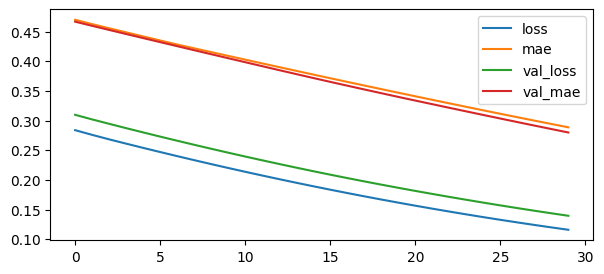

In [ ]:

pd.DataFrame(history.history).plot(figsize=(7,3))
pd.DataFrame(history.history).head()


In [ ]:
import numpy as np

squat_input = np.array([[130]])              # raw bench in kg
bench_input_scaled = scaler.transform(squat_input)

pred_scaled = model.predict(bench_input_scaled)  # output ~0–1
pred_kg = y_scaler.inverse_transform(pred_scaled)

print("Predicted Deadlift (kg):", pred_kg[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


c:\Users\user\Desktop\machine_learning\ts_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Predicted Deadlift (kg): 144.735


In [2]:
import tensorflow as tf
import tensorflowjs as tfjs

# Assuming 'model' is a tf.keras.Model
tfjs.converters.save_keras_model(model, "gym_model")


NotFoundError: c:\Users\user\Desktop\machine_learning\tfjs_env\lib\site-packages\tensorflow_decision_forests\tensorflow\ops\inference\inference.so not found